**DSCB230 Sommersemester 2026**

# Hausarbeit - Unternehmensanaylse anhand des Aktienkurses
Data Science Portfolioprojekt

Gruppe | Studierende 1 | Studierende 2 |
------ | ------ | ------ |
`Foxtrot` | `Ivan Pedzin` | `Maximilian Hutter` |

## Business Case

Es sollen verschiedene Unternehemen, am Beispiel Apple, Microsoft und Samsung, auf Basis ihres Aktienkurses verglichen werden, um Investitionsentscheidungen zu treffen (Zeitraum 2000 - Jetzt).

Dabei werden speziel folgende Punkte untersucht:
- Allgemeiner grafischer Vergleich der Aktienkurse
- Rendite
- Volatilität
- gleitende Durchschnitte 
- Verhalten in Krisenzeiten (versuchen genau Punkte dazustellen)
- Am Beispiel Intel vom 4.5 (2. ZP) bis hin zur Präsentation entwicklung bei 1000€ Investition

## Datenerfassung und Datenvorverarbeitung

### Download des Datensatzes (Yahoo Finance API)

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import streamlit as st
import plotly.graph_objects as go
from datetime import datetime

heute = datetime.now().strftime('%Y-%m-%d')

# Aktien Dictionary, weiter Aktien einfach ergaenzen
aktien = {
    "Apple":     "AAPL",
    "Microsoft": "MSFT",
    "Samsung":   "SMSN.IL"
}

In [2]:
# Daten von 2000
daten = {}
for name, ticker in aktien.items():
    daten[name] = yf.Ticker(ticker).history(start="2000-01-01", end=heute)

### Erster Überblick über die Daten

In [3]:
for name, df in daten.items():
    print(name)
    display(df.head())

Apple


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,0.784870,0.841934,0.761015,0.837724,535796800,0.0,0.0
2000-01-04 00:00:00-05:00,0.810128,0.827901,0.757273,0.767096,512377600,0.0,0.0
2000-01-05 00:00:00-05:00,0.776450,0.827434,0.770837,0.778321,778321600,0.0,0.0
2000-01-06 00:00:00-05:00,0.794225,0.800773,0.710966,0.710966,767972800,0.0,0.0
2000-01-07 00:00:00-05:00,0.722192,0.755870,0.714709,0.744644,460734400,0.0,0.0


Microsoft


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,35.690679,36.070771,34.056281,35.443619,53228400,0.0,0.0
2000-01-04 00:00:00-05:00,34.531400,35.614663,34.132303,34.246330,54119000,0.0,0.0
2000-01-05 00:00:00-05:00,33.790201,35.386588,33.258072,34.607399,64059600,0.0,0.0
2000-01-06 00:00:00-05:00,34.113285,34.626410,32.954004,33.448124,54976600,0.0,0.0
2000-01-07 00:00:00-05:00,33.030012,34.132280,32.630915,33.885220,62013600,0.0,0.0


Samsung


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2001-05-14 00:00:00+01:00,64.127390,64.127390,63.229248,63.588505,197500,0.0,0.0
2001-05-15 00:00:00+01:00,62.683168,63.732197,62.510726,62.733463,122000,0.0,0.0
2001-05-16 00:00:00+01:00,61.792201,62.704711,60.714430,60.894058,278900,0.0,0.0
2001-05-17 00:00:00+01:00,63.954929,64.580032,62.510714,64.299812,364300,0.0,0.0
2001-05-18 00:00:00+01:00,63.337009,64.666259,60.994652,64.256706,199100,0.0,0.0


### Datenbereinigung

#### Fehlende Werte checken

In [4]:
for name, df in daten.items():
    print(f'{name}:')
    print(df.isnull().sum())
#mit isnull schauen ob zellen leer sind und ergebnis (True/False) aller zellen zusammenrechnen


Apple:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Microsoft:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Samsung:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


#### Duplikate Checken

In [5]:
for name, df in daten.items():
    print(f'{name}: {df.index.duplicated().sum()} Duplikate')
# schaut ob ein datum (index) doppelt vorkommt

Apple: 0 Duplikate
Microsoft: 0 Duplikate
Samsung: 0 Duplikate


#### Samsung GDR in einzel Aktien umrechnen

In [6]:
# Samsung Kurse durch 25 teilen (GDR → Einzelaktie: 1 GDR = 25 Stammaktien)
for col in ["Close", "Open", "High", "Low"]:
    daten["Samsung"][col] = daten["Samsung"][col] / 25

## Analyse der Daten

### Kursvergleiche

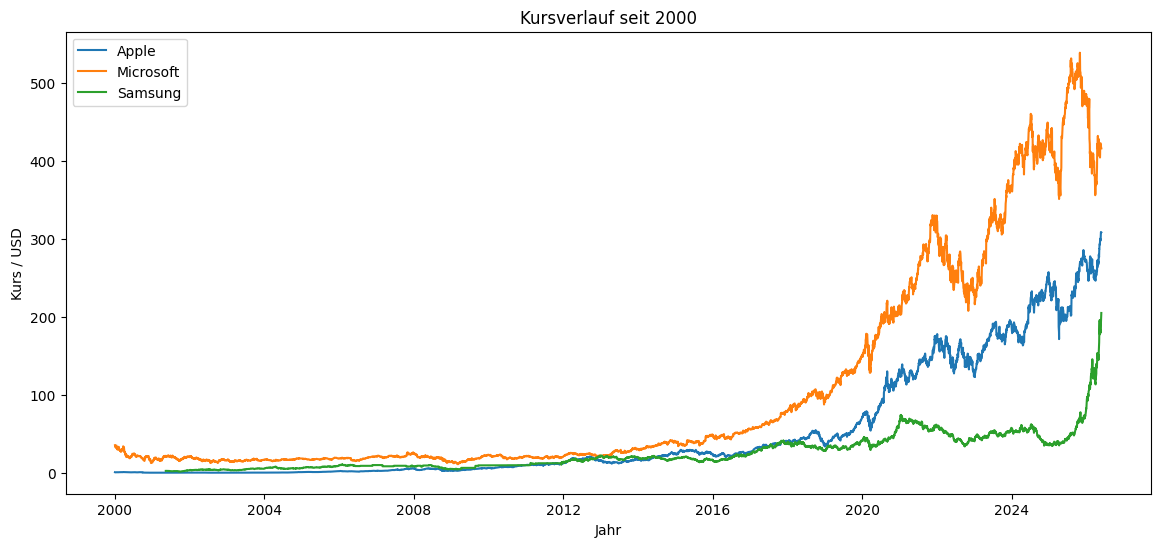

In [7]:
plt.figure(figsize=(14, 6))
for name, df in daten.items():
    plt.plot(df["Close"], label=name)
plt.title("Kursverlauf seit 2000")
plt.xlabel("Jahr")
plt.ylabel("Kurs / USD")
plt.legend()
plt.show()


### Rendite

## Lessons Learned